In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Global plotting style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

RAW_DATA_PATH = "../data/raw/superstore.csv"
CLEAN_DATA_PATH = "../data/processed/superstore_cleaned.csv"
FIGURES_DIR = "../reports/figures"

import os
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

print("Environment ready.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Environment ready.
pandas 3.0.3 | numpy 2.4.6


In [4]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")
df_raw.head()


Loaded 9,800 rows and 18 columns.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print("Shape (rows, columns):", df_raw.shape)
print("\nColumn names:")
print(list(df_raw.columns))
print("\nData types:")
print(df_raw.dtypes)


Shape (rows, columns): (9800, 18)

Column names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data types:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object


In [6]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df_raw.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
Row ID,9800.0,4900.500000,2829.160653,1.000,2450.750,4900.50,7350.250,9800.00
Postal Code,9789.0,55273.322403,32041.223413,1040.000,23223.000,58103.00,90008.000,99301.00
Sales,9800.0,230.769059,626.651875,0.444,17.248,54.49,210.605,22638.48


In [8]:
df_raw.describe(include="object").T


,count,unique,top,freq
Order ID,9800,4922,CA-2018-100111,14
Order Date,9800,1230,05/09/2017,38
Ship Date,9800,1326,26/09/2018,34
Ship Mode,9800,4,Standard Class,5859
Customer ID,9800,793,WB-21850,35
Customer Name,9800,793,William Brown,35
Segment,9800,3,Consumer,5101
Country,9800,1,United States,9800
City,9800,529,New York City,891
State,9800,49,California,1946


In [9]:
def missing_value_report(frame: pd.DataFrame) -> pd.DataFrame:
    '''Return a tidy missing-value summary (count + percentage) per column.

    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame to audit for missing values.

    Returns
    -------
    pd.DataFrame
        Columns: ``missing_count`` and ``missing_pct``, sorted descending,
        limited to columns that actually contain missing values.
    '''
    counts = frame.isna().sum()
    pct = (counts / len(frame) * 100).round(2)
    report = pd.DataFrame({"missing_count": counts, "missing_pct": pct})
    return report[report["missing_count"] > 0].sort_values(
        "missing_count", ascending=False
    )


missing_report = missing_value_report(df_raw)
missing_report


,missing_count,missing_pct
Postal Code,11,0.11


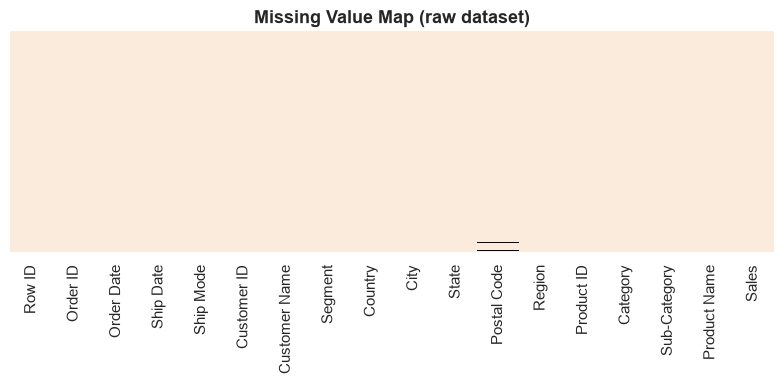

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_raw.isna(), cbar=False, cmap="rocket_r", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (raw dataset)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/00_missingness_map.png", bbox_inches="tight")
plt.show()


In [11]:
def treat_missing_postal_codes(frame: pd.DataFrame) -> pd.DataFrame:
    '''Impute missing ``Postal Code`` values using a City/State lookup.

    Rather than dropping rows or filling with a generic placeholder, missing
    postal codes are resolved using the mode postal code observed for the
    same City/State combination elsewhere in the dataset. This preserves
    every order record while keeping the imputed value accurate.

    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame containing ``City``, ``State`` and ``Postal Code`` columns.

    Returns
    -------
    pd.DataFrame
        Copy of ``frame`` with missing postal codes imputed.
    '''
    frame = frame.copy()
    lookup = (
        frame.dropna(subset=["Postal Code"])
        .groupby(["City", "State"])["Postal Code"]
        .agg(lambda s: s.mode().iloc[0])
    )

    missing_mask = frame["Postal Code"].isna()
    for idx in frame.index[missing_mask]:
        key = (frame.loc[idx, "City"], frame.loc[idx, "State"])
        if key in lookup.index:
            frame.loc[idx, "Postal Code"] = lookup.loc[key]

    return frame


df = treat_missing_postal_codes(df_raw)
remaining_missing = df["Postal Code"].isna().sum()
print(f"Remaining missing Postal Code values after imputation: {remaining_missing}")
df.loc[df_raw["Postal Code"].isna(), ["City", "State", "Postal Code"]].head()


Remaining missing Postal Code values after imputation: 11


,City,State,Postal Code
2234,Burlington,Vermont,NaN
5274,Burlington,Vermont,NaN
8798,Burlington,Vermont,NaN
9146,Burlington,Vermont,NaN
9147,Burlington,Vermont,NaN


In [12]:
def find_duplicates(frame: pd.DataFrame, ignore_cols=("Row ID",)) -> pd.DataFrame:
    '''Identify duplicate rows, ignoring columns that are expected to
    differ even for genuine duplicates (e.g. a surrogate row ID).

    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame to inspect.
    ignore_cols : tuple[str]
        Columns excluded from the duplicate comparison.

    Returns
    -------
    pd.DataFrame
        All rows involved in a duplicate group (keep=False), for review.
    '''
    compare_cols = [c for c in frame.columns if c not in ignore_cols]
    dup_mask = frame.duplicated(subset=compare_cols, keep=False)
    return frame.loc[dup_mask].sort_values(compare_cols)


duplicate_rows = find_duplicates(df)
print(f"Duplicate rows found: {len(duplicate_rows)}")
duplicate_rows


Duplicate rows found: 2


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3405,3406,US-2015-150119,23/04/2015,27/04/2015,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229.0,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372
3406,3407,US-2015-150119,23/04/2015,27/04/2015,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229.0,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372


In [13]:
before = len(df)
compare_cols = [c for c in df.columns if c != "Row ID"]
df = df.drop_duplicates(subset=compare_cols, keep="first").reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate row(s). New shape: {df.shape}")


Removed 1 duplicate row(s). New shape: (9799, 18)


In [14]:
def fix_data_types(frame: pd.DataFrame) -> pd.DataFrame:
    '''Correct column data types: parse dates, cast Postal Code to
    nullable integer, and ensure Sales is numeric.

    Parameters
    ----------
    frame : pd.DataFrame
        Cleaned-so-far DataFrame.

    Returns
    -------
    pd.DataFrame
        Copy of ``frame`` with corrected dtypes.
    '''
    frame = frame.copy()
    frame["Order Date"] = pd.to_datetime(frame["Order Date"], dayfirst=True, errors="coerce")
    frame["Ship Date"] = pd.to_datetime(frame["Ship Date"], dayfirst=True, errors="coerce")
    frame["Postal Code"] = frame["Postal Code"].astype("Int64")
    frame["Sales"] = pd.to_numeric(frame["Sales"], errors="coerce")
    return frame


df = fix_data_types(df)
print(df[["Order Date", "Ship Date", "Postal Code", "Sales"]].dtypes)
print("\nUnparsed dates after coercion:",
      df["Order Date"].isna().sum() + df["Ship Date"].isna().sum())


Order Date     datetime64[us]
Ship Date      datetime64[us]
Postal Code             Int64
Sales                 float64
dtype: object

Unparsed dates after coercion: 0


In [15]:
CATEGORICAL_COLS = [
    "Ship Mode", "Segment", "Country", "City", "State",
    "Region", "Category", "Sub-Category",
]

def optimize_categories(frame: pd.DataFrame, cat_cols=CATEGORICAL_COLS) -> pd.DataFrame:
    '''Trim whitespace, normalize casing, and cast text columns to
    pandas ``category`` dtype for memory efficiency and faster group-bys.

    Parameters
    ----------
    frame : pd.DataFrame
        DataFrame to optimize.
    cat_cols : list[str]
        Column names to treat as categorical.

    Returns
    -------
    pd.DataFrame
        Copy of ``frame`` with normalized, categorical-typed columns.
    '''
    frame = frame.copy()
    for col in cat_cols:
        frame[col] = (
            frame[col]
            .astype(str)
            .str.strip()
            .str.title()
            .astype("category")
        )
    return frame


mem_before = df.memory_usage(deep=True).sum() / 1024 ** 2
df = optimize_categories(df)
mem_after = df.memory_usage(deep=True).sum() / 1024 ** 2
print(f"Memory usage: {mem_before:.2f} MB -> {mem_after:.2f} MB "
      f"({(1 - mem_after / mem_before):.1%} reduction)")
for col in CATEGORICAL_COLS[:4]:
    print(f"{col}: {df[col].cat.categories.tolist()}")


Memory usage: 7.89 MB -> 3.62 MB (54.1% reduction)
Ship Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']
Segment: ['Consumer', 'Corporate', 'Home Office']
Country: ['United States']
City: ['Aberdeen', 'Abilene', 'Akron', 'Albuquerque', 'Alexandria', 'Allen', 'Allentown', 'Altoona', 'Amarillo', 'Anaheim', 'Andover', 'Ann Arbor', 'Antioch', 'Apopka', 'Apple Valley', 'Appleton', 'Arlington', 'Arlington Heights', 'Arvada', 'Asheville', 'Athens', 'Atlanta', 'Atlantic City', 'Auburn', 'Aurora', 'Austin', 'Avondale', 'Bakersfield', 'Baltimore', 'Bangor', 'Bartlett', 'Bayonne', 'Baytown', 'Beaumont', 'Bedford', 'Belleville', 'Bellevue', 'Bellingham', 'Bethlehem', 'Beverly', 'Billings', 'Bloomington', 'Boca Raton', 'Boise', 'Bolingbrook', 'Bossier City', 'Bowling Green', 'Boynton Beach', 'Bozeman', 'Brentwood', 'Bridgeton', 'Bristol', 'Broken Arrow', 'Broomfield', 'Brownsville', 'Bryan', 'Buffalo', 'Buffalo Grove', 'Bullhead City', 'Burbank', 'Burlington', 'Caldwell', 'Camari

In [16]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Year-Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Order Day of Week"] = df["Order Date"].dt.day_name()
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Order Year", "Order Month",
    "Order Year-Month", "Order Day of Week", "Shipping Days"]].head()


,Order Date,Ship Date,Order Year,Order Month,Order Year-Month,Order Day of Week,Shipping Days
0,2017-11-08,2017-11-11,2017,11,2017-11,Wednesday,3
1,2017-11-08,2017-11-11,2017,11,2017-11,Wednesday,3
2,2017-06-12,2017-06-16,2017,6,2017-06,Monday,4
3,2016-10-11,2016-10-18,2016,10,2016-10,Tuesday,7
4,2016-10-11,2016-10-18,2016,10,2016-10,Tuesday,7


In [17]:
def detect_outliers_iqr(frame: pd.DataFrame, column: str) -> tuple[pd.Series, float, float]:
    '''Flag IQR-method outliers for a numeric column.

    Parameters
    ----------
    frame : pd.DataFrame
        Source DataFrame.
    column : str
        Numeric column to evaluate.

    Returns
    -------
    tuple[pd.Series, float, float]
        Boolean mask of outlier rows, lower bound, upper bound.
    '''
    q1, q3 = frame[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (frame[column] < lower_bound) | (frame[column] > upper_bound)
    return mask, lower_bound, upper_bound


sales_outlier_mask, sales_lb, sales_ub = detect_outliers_iqr(df, "Sales")
ship_outlier_mask, ship_lb, ship_ub = detect_outliers_iqr(df, "Shipping Days")

print(f"Sales IQR bounds: [{sales_lb:.2f}, {sales_ub:.2f}]")
print(f"Sales outliers: {sales_outlier_mask.sum():,} rows "
      f"({sales_outlier_mask.mean():.2%} of data)")
print(f"\nShipping Days IQR bounds: [{ship_lb:.2f}, {ship_ub:.2f}]")
print(f"Shipping Days outliers: {ship_outlier_mask.sum():,} rows "
      f"({ship_outlier_mask.mean():.2%} of data)")


Sales IQR bounds: [-272.74, 500.56]
Sales outliers: 1,145 rows (11.68% of data)

Shipping Days IQR bounds: [0.00, 8.00]
Shipping Days outliers: 0 rows (0.00% of data)


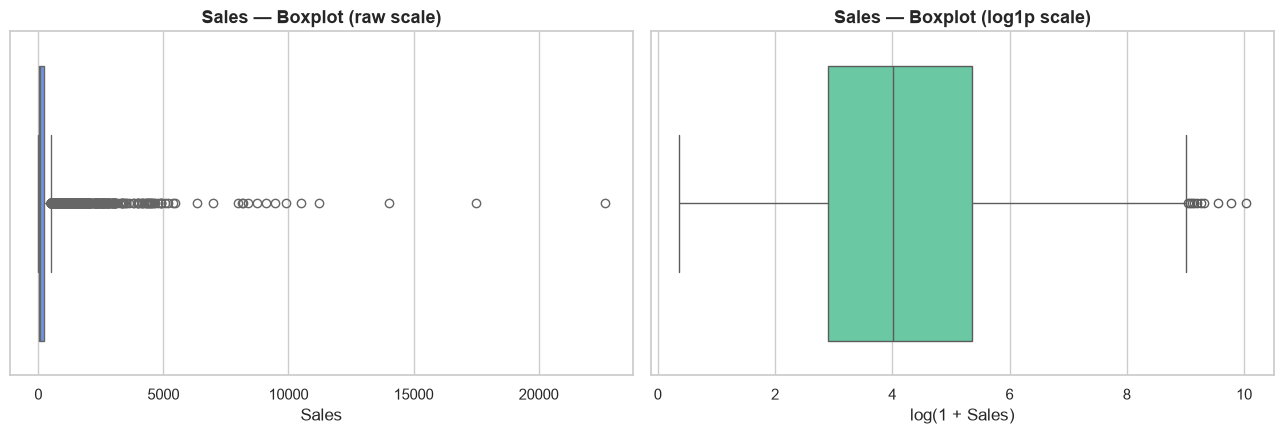

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df["Sales"], ax=axes[0], color="#5B8FF9")
axes[0].set_title("Sales — Boxplot (raw scale)")
sns.boxplot(x=np.log1p(df["Sales"]), ax=axes[1], color="#5AD8A6")
axes[1].set_title("Sales — Boxplot (log1p scale)")
axes[1].set_xlabel("log(1 + Sales)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_sales_outlier_boxplots.png", bbox_inches="tight")
plt.show()


In [19]:
def treat_outliers_iqr(frame: pd.DataFrame, column: str, lower: float, upper: float) -> pd.DataFrame:
    '''Add an outlier flag and a winsorized (capped) helper column for a
    numeric field, without discarding the original values.

    Parameters
    ----------
    frame : pd.DataFrame
        Source DataFrame.
    column : str
        Numeric column that was IQR-tested.
    lower, upper : float
        IQR bounds computed by :func:`detect_outliers_iqr`.

    Returns
    -------
    pd.DataFrame
        Copy of ``frame`` with two new columns: ``f"{column}_outlier_flag"``
        and ``f"{column}_capped"``.
    '''
    frame = frame.copy()
    frame[f"{column}_outlier_flag"] = (frame[column] < lower) | (frame[column] > upper)
    frame[f"{column}_capped"] = frame[column].clip(lower=max(lower, 0), upper=upper)
    return frame


df = treat_outliers_iqr(df, "Sales", sales_lb, sales_ub)
df = treat_outliers_iqr(df, "Shipping Days", ship_lb, ship_ub)
print("New columns added:",
      [c for c in df.columns if "outlier_flag" in c or "_capped" in c])
df[["Sales", "Sales_capped", "Sales_outlier_flag"]].sample(5, random_state=1)


New columns added: ['Sales_outlier_flag', 'Sales_capped', 'Shipping Days_outlier_flag', 'Shipping Days_capped']


,Sales,Sales_capped,Sales_outlier_flag
2573,526.450,500.558,True
7639,68.040,68.040,False
1755,360.712,360.712,False
7766,7.152,7.152,False
6970,89.584,89.584,False


In [20]:
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"Cleaned dataset saved -> {CLEAN_DATA_PATH}")
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Cleaned dataset saved -> ../data/processed/superstore_cleaned.csv
Final shape: 9,799 rows x 27 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Order Year,Order Month,Order Year-Month,Order Day of Week,Shipping Days,Sales_outlier_flag,Sales_capped,Shipping Days_outlier_flag,Shipping Days_capped
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2017,11,2017-11,Wednesday,3,False,261.960,False,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,2017,11,2017-11,Wednesday,3,True,500.558,False,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2017,6,2017-06,Monday,4,False,14.620,False,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,2016,10,2016-10,Tuesday,7,True,500.558,False,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2016,10,2016-10,Tuesday,7,False,22.368,False,7


In [21]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
Row ID,9799.0,4900.652414,2829.264788,1.0,2450.5,4901.0,7350.5,9800.0
Postal Code,9788.0,55274.552922,32042.628986,1040.0,23223.0,58103.0,90008.0,99301.0
Sales,9799.0,230.763895,626.683644,0.444,17.248,54.48,210.572,22638.48
Order Year,9799.0,2016.72436,1.123906,2015.0,2016.0,2017.0,2018.0,2018.0
Order Month,9799.0,7.818859,3.281846,1.0,5.0,9.0,11.0,12.0
Shipping Days,9799.0,3.961118,1.749703,0.0,3.0,4.0,5.0,7.0
Sales_capped,9799.0,140.791806,169.533857,0.444,17.248,54.48,210.572,500.558
Shipping Days_capped,9799.0,3.961118,1.749703,0.0,3.0,4.0,5.0,7.0


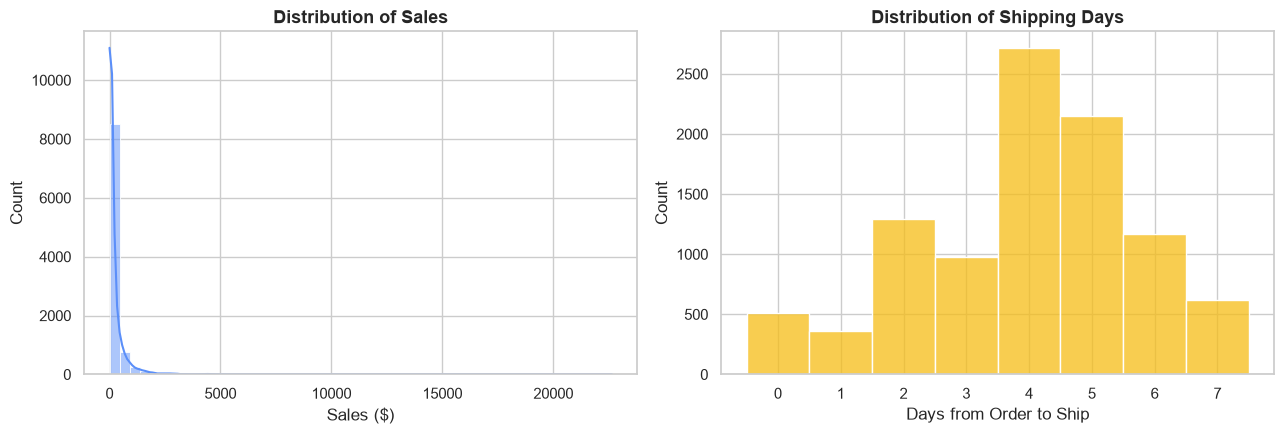

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="#5B8FF9")
axes[0].set_title("Distribution of Sales")
axes[0].set_xlabel("Sales ($)")

sns.histplot(df["Shipping Days"], bins=range(0, 10), kde=False,
             ax=axes[1], color="#F6BD16", discrete=True)
axes[1].set_title("Distribution of Shipping Days")
axes[1].set_xlabel("Days from Order to Ship")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_histograms.png", bbox_inches="tight")
plt.show()


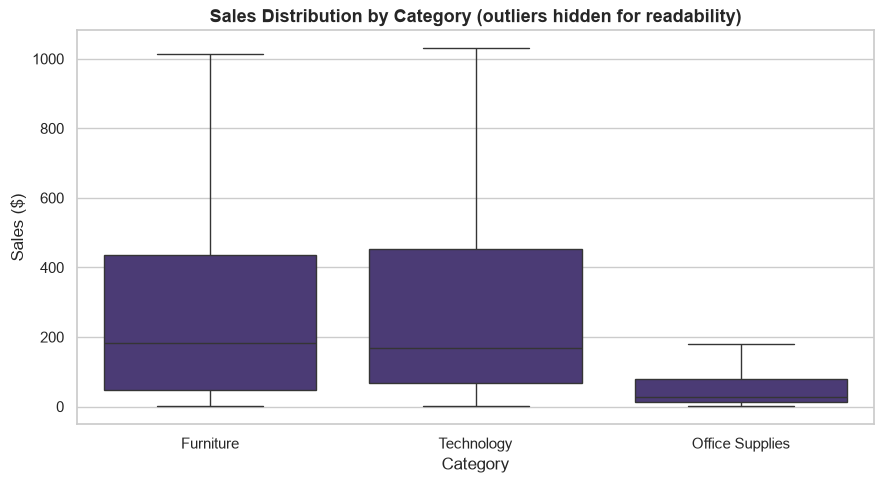

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
order = df.groupby("Category")["Sales"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Category", y="Sales", order=order, ax=ax, showfliers=False)
ax.set_title("Sales Distribution by Category (outliers hidden for readability)")
ax.set_ylabel("Sales ($)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_boxplot_sales_by_category.png", bbox_inches="tight")
plt.show()


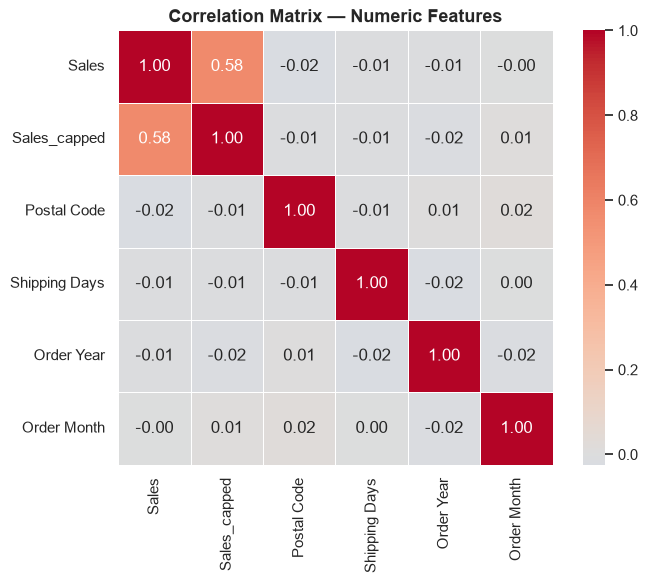

In [24]:
numeric_cols = ["Sales", "Sales_capped", "Postal Code", "Shipping Days", "Order Year", "Order Month"]
corr = df[numeric_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_correlation_heatmap.png", bbox_inches="tight")
plt.show()


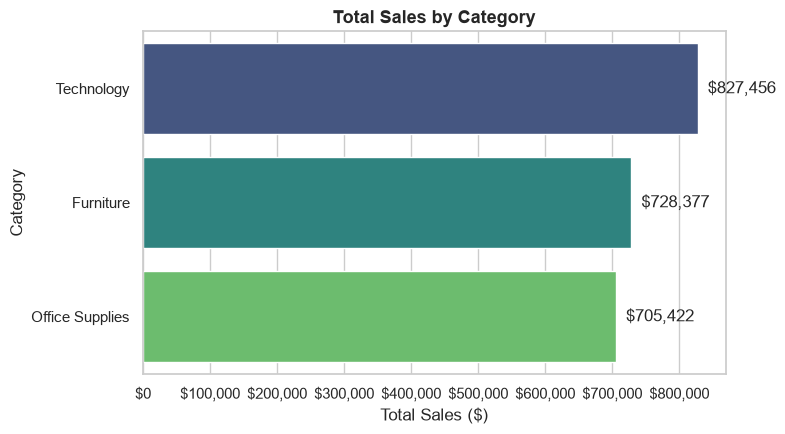

In [25]:
cat_sales = df.groupby("Category", observed=True)["Sales"].sum().sort_values(ascending=False)
# NOTE: convert the (categorical-dtype) index to plain strings before handing
# it to seaborn -- seaborn silently re-sorts a categorical axis into its
# *intrinsic* category order, which would desynchronize bar heights from
# their labels if the CategoricalIndex were passed through directly.
cat_sales.index = cat_sales.index.astype(str)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=ax, palette="viridis")
ax.set_title("Total Sales by Category")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for i, v in enumerate(cat_sales.values):
    ax.text(v, i, f"  ${v:,.0f}", va="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_sales_by_category.png", bbox_inches="tight")
plt.show()


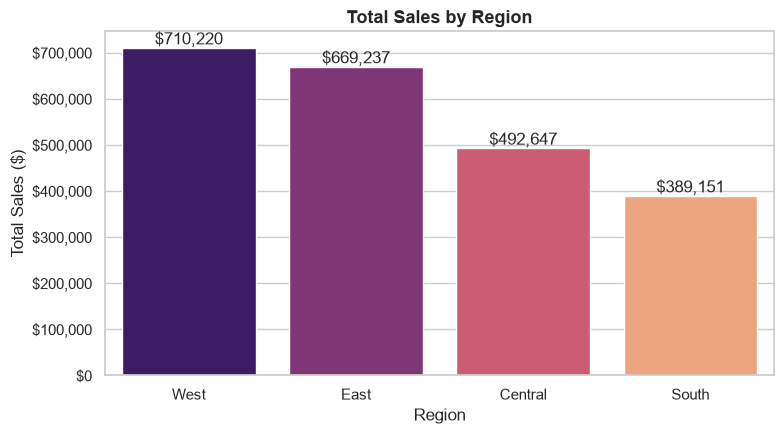

In [26]:
region_sales = df.groupby("Region", observed=True)["Sales"].sum().sort_values(ascending=False)
region_sales.index = region_sales.index.astype(str)  # see note above re: categorical axes

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=region_sales.index, y=region_sales.values, ax=ax, palette="magma")
ax.set_title("Total Sales by Region")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for i, v in enumerate(region_sales.values):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/06_sales_by_region.png", bbox_inches="tight")
plt.show()


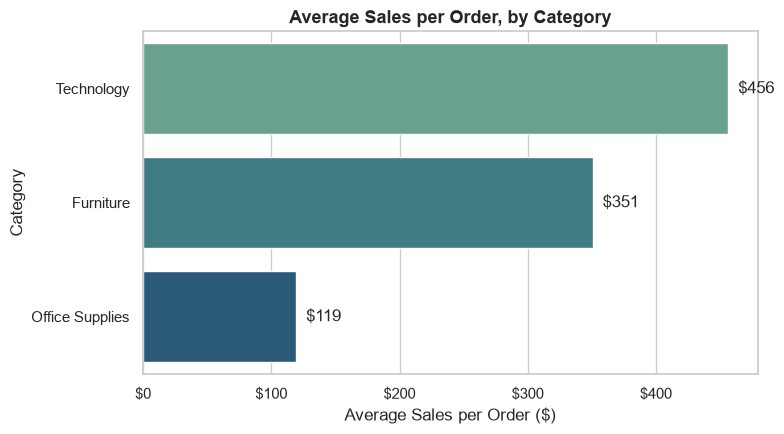

In [27]:
avg_order_value = df.groupby("Category", observed=True)["Sales"].mean().sort_values(ascending=False)
avg_order_value.index = avg_order_value.index.astype(str)  # see note above re: categorical axes

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=avg_order_value.values, y=avg_order_value.index, ax=ax, palette="crest")
ax.set_title("Average Sales per Order, by Category")
ax.set_xlabel("Average Sales per Order ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
for i, v in enumerate(avg_order_value.values):
    ax.text(v, i, f"  ${v:,.0f}", va="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/07_avg_sales_by_category.png", bbox_inches="tight")
plt.show()


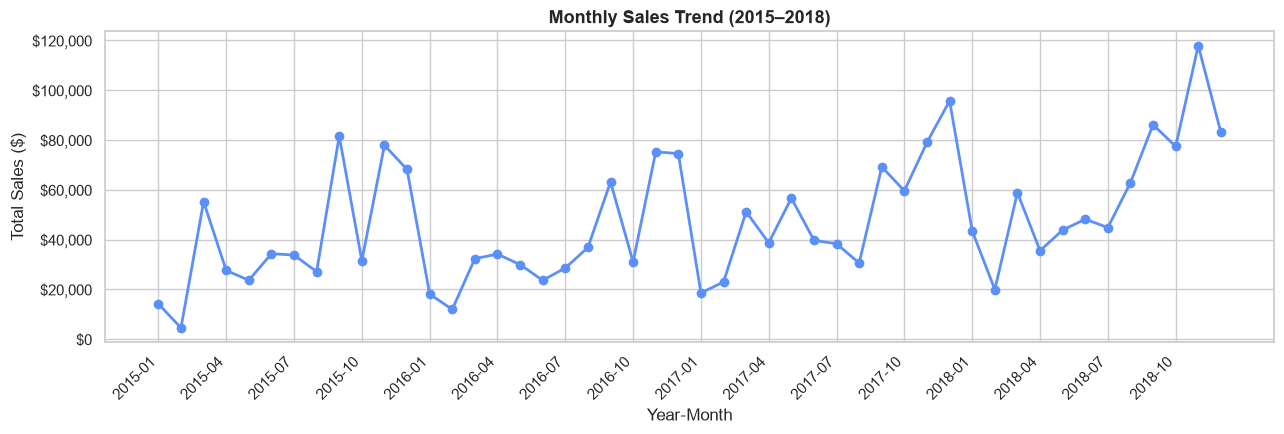

In [28]:
monthly_sales = df.groupby("Order Year-Month")["Sales"].sum().sort_index()

fig, ax = plt.subplots(figsize=(13, 4.5))
monthly_sales.plot(ax=ax, marker="o", color="#5B8FF9", linewidth=2)
ax.set_title("Monthly Sales Trend (2015–2018)")
ax.set_xlabel("Year-Month")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
step = 3
ax.set_xticks(range(0, len(monthly_sales), step))
ax.set_xticklabels(monthly_sales.index[::step], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/08_monthly_sales_trend.png", bbox_inches="tight")
plt.show()


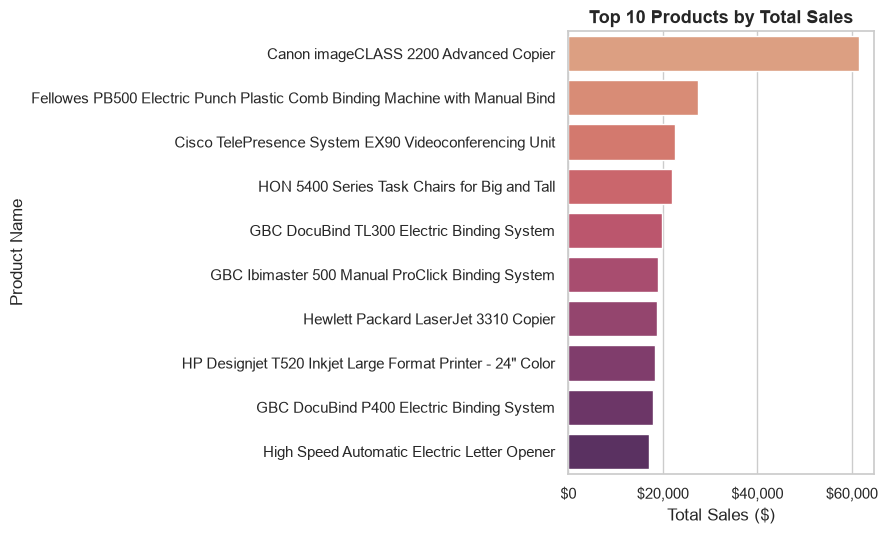

In [29]:
top_products = (
    df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, palette="flare")
ax.set_title("Top 10 Products by Total Sales")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/09_top10_products.png", bbox_inches="tight")
plt.show()


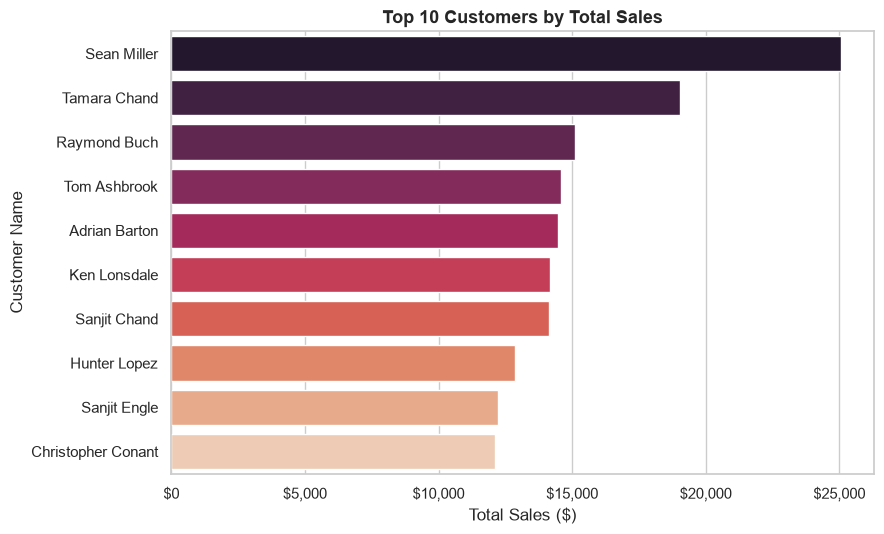

In [30]:
top_customers = (
    df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=top_customers.values, y=top_customers.index, ax=ax, palette="rocket")
ax.set_title("Top 10 Customers by Total Sales")
ax.set_xlabel("Total Sales ($)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/10_top10_customers.png", bbox_inches="tight")
plt.show()


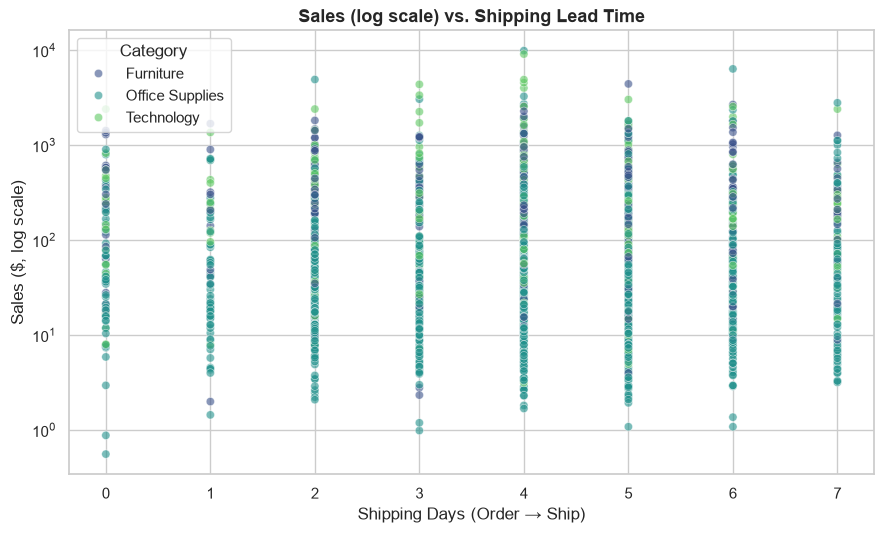

In [31]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sample = df.sample(min(2000, len(df)), random_state=1)
sns.scatterplot(data=sample, x="Shipping Days", y="Sales", hue="Category",
                 alpha=0.6, ax=ax, palette="viridis")
ax.set_yscale("log")
ax.set_title("Sales (log scale) vs. Shipping Lead Time")
ax.set_xlabel("Shipping Days (Order → Ship)")
ax.set_ylabel("Sales ($, log scale)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/11_sales_vs_shipping_days.png", bbox_inches="tight")
plt.show()


In [32]:
total_sales = df["Sales"].sum()
n_customers = df["Customer Name"].nunique()
n_orders = df["Order ID"].nunique()

cat_stats = df.groupby("Category", observed=True)["Sales"].agg(["sum", "mean", "count"])
top_region_share = region_sales.iloc[0] / total_sales
top10pct_customers = max(1, int(0.10 * n_customers))
customer_rev = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
top10pct_share = customer_rev.head(top10pct_customers).sum() / total_sales

weekday_sales = df.groupby("Order Day of Week")["Sales"].sum().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
busiest_weekday = weekday_sales.idxmax()
weakest_weekday = weekday_sales.idxmin()

shipmode_share = df["Ship Mode"].value_counts(normalize=True)
avg_ship_days_by_mode = df.groupby("Ship Mode", observed=True)["Shipping Days"].mean().sort_values()
outlier_pct = df["Sales_outlier_flag"].mean()

print(f"Total Sales (2015-2018): ${total_sales:,.0f}")
print(f"Unique Orders: {n_orders:,} | Unique Customers: {n_customers:,}")
print(f"\nPer-category Sales (sum / avg order value / order count):\n{cat_stats}")
print(f"\nTop region ({region_sales.index[0]}) share of revenue: {top_region_share:.1%}")
print(f"Top 10% of customers contribute: {top10pct_share:.1%} of revenue")
print(f"Busiest weekday by Sales: {busiest_weekday} | Weakest: {weakest_weekday}")
print(f"Sales outlier rate (IQR method): {outlier_pct:.1%}")
print(f"\nShip Mode usage:\n{shipmode_share.round(3)}")
print(f"\nAvg shipping days by mode:\n{avg_ship_days_by_mode.round(2)}")


Total Sales (2015-2018): $2,261,255
Unique Orders: 4,922 | Unique Customers: 793

Per-category Sales (sum / avg order value / order count):
                         sum        mean  count
Category                                       
Furniture        728377.2037  350.687147   2077
Office Supplies  705422.3340  119.381001   5909
Technology       827455.8730  456.401474   1813

Top region (West) share of revenue: 31.4%
Top 10% of customers contribute: 30.9% of revenue
Busiest weekday by Sales: Saturday | Weakest: Thursday
Sales outlier rate (IQR method): 11.7%

Ship Mode usage:
Ship Mode
Standard Class    0.598
Second Class      0.194
First Class       0.153
Same Day          0.055
Name: proportion, dtype: float64

Avg shipping days by mode:
Ship Mode
Same Day          0.04
First Class       2.18
Second Class      3.25
Standard Class    5.01
Name: Shipping Days, dtype: float64
